In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1. The Dataset

5 features $x_1, \dots, x_5$, 30 samples. The target is generated from **known true weights** plus a little Gaussian noise:

$$y = 2.5x_1 - 1.0x_2 + 0.5x_3 + 3.0x_4 - 2.0x_5 + 4.0 + \varepsilon$$

Knowing the true weights in advance lets us check that gradient descent actually finds them — this is the standard way to sanity-check a from-scratch implementation before trusting it on real data.

In [2]:
rng = np.random.default_rng(42)

n_samples, n_features = 30, 5

X = rng.uniform(0, 10, size=(n_samples, n_features)).round(2)

true_w = np.array([2.5, -1.0, 0.5, 3.0, -2.0])
true_b = 4.0
# noise = rng.normal(0, 1.0, size=n_samples)

y = (X @ true_w + true_b).round(2)

feature_names = [f"x{i+1}" for i in range(n_features)]
df = pd.DataFrame(X, columns=feature_names)
df["y"] = y
df.head()

,x1,x2,x3,x4,x5,y
0,7.74,4.39,8.59,6.97,0.94,42.28
1,9.76,7.61,7.86,1.28,4.50,19.56
2,3.71,9.27,6.44,8.23,4.43,23.06
3,2.27,5.55,0.64,8.28,6.32,16.64
4,7.58,3.55,9.71,8.93,7.78,35.48


In [4]:
def train_test_split(X, y, test_frac=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(X))
    n_test = int(len(X) * test_frac)
    test_idx, train_idx = idx[:n_test], idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_frac=0.2, seed=0)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (24, 5)  Test: (6, 5)


## 3. Feature Standardisation

The 5 features aren't on the same scale, which makes gradient descent slow and finicky (some weights need huge steps, others tiny ones). Standardising each feature to mean 0, std 1 fixes this. We compute mean/std **from the training set only** and apply it to both sets, to avoid leaking test information.

In [5]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

X_train_s = (X_train - mu) / sigma
X_test_s = (X_test - mu) / sigma

print("Feature means (train, standardized):", X_train_s.mean(axis=0), X_train_s.shape)
print("Feature stds  (train, standardized):", X_train_s.std(axis=0), X_test_s.shape)

Feature means (train, standardized): [-0.  0. -0. -0. -0.] (24, 5)
Feature stds  (train, standardized): [1. 1. 1. 1. 1.] (6, 5)


## 4. Random Weight Initialisation

This is the step your students are practicing: draw random starting weights (and bias) rather than picking anything meaningful.

In [6]:
rng_init = np.random.default_rng()   # separate RNG just for weight init

w = rng_init.normal(loc=0.0, scale=1.0, size=n_features)
b = 0.0

print("Randomly initialised weights:", w, w.shape)
print("Randomly initialised bias:   ", b)

Randomly initialised weights: [ 0.8068  0.351   0.4968 -0.9256  0.941 ] (5,)
Randomly initialised bias:    0.0


In [7]:
def predict(X,w,b):
    return X @ w + b

def compute_loss(X,w,b,y):
    error = predict(X,w,b) - y
    return np.mean(error**2)


def gradient(X, y, y_hat):
    error = y_hat - y
    m = len(X)
    # print("X Shape = ",X.T.shape)
    # print("error shape = ",error.shape)
    dL_dw = (2/m)*(X.T @ error)
    dL_db = (2/m)*np.sum(error)

    return dL_dw, dL_db


print(predict(X_train_s, w, b))
print(gradient(X_train_s, y_train, predict(X_train_s, w, b)))

[ 0.3728  0.4931  2.488   1.4804 -1.0685  0.7305 -2.2635 -2.2901  2.4267
 -0.6879  2.2488  0.0456  0.3262  1.319  -0.0537  0.0132  0.2466 -0.877
 -2.3166 -1.5124 -3.1027 -1.4993  3.4581  0.0226]
(array([-12.5145,   1.9778,  -6.4954, -19.4961,  14.6299]), np.float64(-34.08416666666666))


In [ ]:
std = 1/m*((x - x_d)**2)

In [22]:
rng_init = np.random.default_rng(7)   # separate RNG just for weight init
w, b = rng_init.normal(loc=0.0, scale=1.0, size=n_features), 0.0

print("Randomly initialised weights:", w, w.shape)
print("Randomly initialised bias:   ", b)

history = []
n_epocs = 100
lr = 0.1
for epoch in range(n_epocs):

    y_hat = predict(X_train_s, w, b)
    grad_w, grad_b = gradient(X_train_s, y_train, y_hat)

    w = w - lr*(grad_w)
    b = b - lr*(grad_b)

    
    history.append((epoch, compute_loss(X_train_s, w, b, y_train)))

print("Final weights:", w, w.shape)
print("Final bias:   ", b)


Randomly initialised weights: [ 0.0012  0.2987 -0.2741 -0.8906 -0.4547] (5,)
Randomly initialised bias:    0.0
Final weights: [ 6.842  -2.2188  1.3688  7.8633 -5.7539] (5,)
Final bias:    17.042083329861807


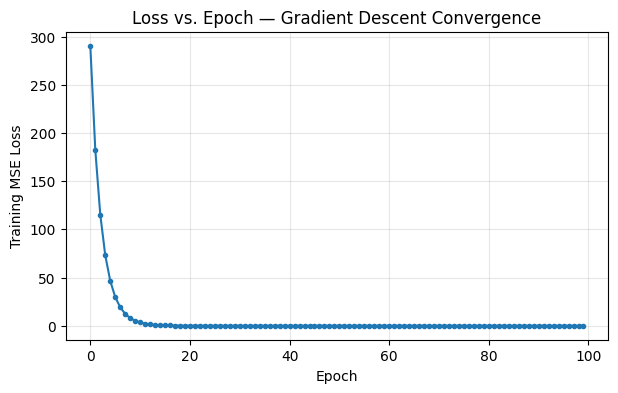

In [23]:
epochs_logged, losses_logged = zip(*history)

plt.figure(figsize=(7, 4))
plt.plot(epochs_logged, losses_logged, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Training MSE Loss")
plt.title("Loss vs. Epoch — Gradient Descent Convergence")
plt.grid(alpha=0.3)
plt.show()

## 7. Convert Weights Back to the Original (Unstandardised) Scale

We trained on standardised features, so the learned weights live in "standardised space". To compare against the true weights we generated the data with, convert back:

$$w_{orig} = \frac{w_{std}}{\sigma} \qquad b_{orig} = b_{std} - \sum \frac{w_{std} \cdot \mu}{\sigma}$$

In [54]:
w_orig = w / sigma
b_orig = b - np.sum(w * mu / sigma)

comparison = pd.DataFrame({
    "feature": feature_names,
    "true_weight": true_w,
    "learned_weight (gradient descent)": w_orig,
})
print(comparison.to_string(index=False))
print(f"\ntrue_bias = {true_b:.4f}   learned_bias = {b_orig:.4f}")

feature  true_weight  learned_weight (gradient descent)
     x1          2.5                           2.438727
     x2         -1.0                          -0.930492
     x3          0.5                           0.542532
     x4          3.0                           2.954473
     x5         -2.0                          -1.959810

true_bias = 4.0000   learned_bias = 3.4320


## 8. Check Against the Closed-Form Solution (Normal Equation)

Linear regression has an exact analytical solution:

$$\theta^{*} = (X^{T}X)^{-1}X^{T}y$$

If gradient descent worked correctly, its answer should closely match this.

In [51]:
X_train_b = np.hstack([X_train, np.ones((len(X_train), 1))])   # add bias column
theta_closed_form = np.linalg.pinv(X_train_b.T @ X_train_b) @ X_train_b.T @ y_train

closed_form_df = pd.DataFrame({
    "feature": feature_names + ["bias"],
    "closed_form_weight": theta_closed_form,
    "gradient_descent_weight": np.append(w_orig, b_orig),
})
print(closed_form_df.to_string(index=False))

feature  closed_form_weight  gradient_descent_weight
     x1            2.499944                 0.941256
     x2           -1.000626                -0.365305
     x3            0.500390                 0.238348
     x4            2.999567                 1.188311
     x5           -1.999787                -0.644196
   bias            4.002502                -5.360731
